In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,root_mean_squared_error,mean_squared_error,r2_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\vidit\Downloads\watches_cleaned.csv")

In [3]:
df.head(10)

,price,brand,model,ref,yop,cond,sex,size
0,43500.0,Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,2019.0,Unworn,Men's watch/Unisex,42.0
1,71500.0,Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,2012.0,Very good,Men's watch/Unisex,39.0
2,79191.0,Audemars Piguet,Royal Oak Chronograph,26331ST,2020.0,Unworn,Unknown,41.0
3,108000.0,Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,2022.0,New,Men's watch/Unisex,38.0
4,27500.0,Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,2020.0,Very good,Men's watch/Unisex,40.0
5,41000.0,Audemars Piguet,Royal Oak Offshore Diver,15710ST.OO.A051CA.01,2018.0,Unworn,Men's watch/Unisex,42.0
6,43500.0,Audemars Piguet,Royal Oak Offshore Diver Chronograph,26703ST.OO.A051CA.01,2016.0,Very good,Men's watch/Unisex,42.0
7,37800.0,Audemars Piguet,Royal Oak Offshore Chronograph,26470IO.OO.A006CA.01,2019.0,Very good,Men's watch/Unisex,42.0
8,32182.0,Audemars Piguet,Royal Oak Dual Time,26120ST.OO.1220ST.03,2015.0,Good,Men's watch/Unisex,39.0
9,36473.0,Audemars Piguet,Royal Oak Offshore Chronograph,26401.RO.OO.A002.CA.01,2016.0,Good,Men's watch/Unisex,44.0


In [4]:
df.tail(10)

,price,brand,model,ref,yop,cond,sex,size
284481,8895.0,Zenith,Chronomaster Sport,03.3100.3600/21.M3100,2023.0,Unworn,Unknown,40.0
284482,2995.0,Zenith,Elite,01.0125.680,2008.0,Very good,Men's watch/Unisex,37.0
284483,9950.0,Zenith,Defy,95.9100.9004/01.I001,2022.0,Very good,Men's watch/Unisex,45.0
284484,6671.0,Zenith,El Primero Chronomaster,03.2160.4047,2020.0,Good,Men's watch/Unisex,45.0
284485,4950.0,Zenith,Unknown,03.A384.400/385.M385,2020.0,Unworn,Unknown,37.0
284486,9790.0,Zenith,Defy El Primero,95.9000.9004/78.M9000,2022.0,Very good,Men's watch/Unisex,44.0
284487,8450.0,Zenith,Chronomaster Sport,03.3100.3600/69.M3100,2021.0,Very good,Men's watch/Unisex,41.0
284488,16500.0,Zenith,El Primero,30.A386.400/69.C807,2019.0,Very good,Men's watch/Unisex,38.0
284489,9000.0,Zenith,Chronomaster Sport,03.3100.3600/69.M3100,2021.0,Unworn,Men's watch/Unisex,41.0
284490,6833.0,Zenith,El Primero Chronomaster,NaN,2019.0,Very good,Unknown,42.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284491 entries, 0 to 284490
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   price   284491 non-null  float64
 1   brand   284491 non-null  object 
 2   model   284491 non-null  object 
 3   ref     241339 non-null  object 
 4   yop     284491 non-null  float64
 5   cond    284491 non-null  object 
 6   sex     284491 non-null  object 
 7   size    284491 non-null  float64
dtypes: float64(3), object(5)
memory usage: 17.4+ MB


In [6]:
df.describe()

,price,yop,size
count,2.844910e+05,284491.000000,284491.000000
mean,1.791111e+04,2013.137017,39.611253
std,6.395579e+04,17.301463,101.293699
min,1.000000e+01,1559.000000,0.000000
25%,3.209000e+03,2015.000000,38.000000
50%,6.899000e+03,2020.000000,40.000000
75%,1.509000e+04,2022.000000,41.500000
max,9.000000e+06,2024.000000,50611.000000


In [7]:
df.isnull().sum()

price        0
brand        0
model        0
ref      43152
yop          0
cond         0
sex          0
size         0
dtype: int64

In [8]:
df.shape

(284491, 8)

In [9]:
df.columns

Index(['price', 'brand', 'model', 'ref', 'yop', 'cond', 'sex', 'size'], dtype='object')

In [10]:
x=df.drop('price',axis=1)
y=df['price']

In [11]:
x

,brand,model,ref,yop,cond,sex,size
0,Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,2019.0,Unworn,Men's watch/Unisex,42.0
1,Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,2012.0,Very good,Men's watch/Unisex,39.0
2,Audemars Piguet,Royal Oak Chronograph,26331ST,2020.0,Unworn,Unknown,41.0
3,Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,2022.0,New,Men's watch/Unisex,38.0
4,Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,2020.0,Very good,Men's watch/Unisex,40.0
...,...,...,...,...,...,...,...
284486,Zenith,Defy El Primero,95.9000.9004/78.M9000,2022.0,Very good,Men's watch/Unisex,44.0
284487,Zenith,Chronomaster Sport,03.3100.3600/69.M3100,2021.0,Very good,Men's watch/Unisex,41.0
284488,Zenith,El Primero,30.A386.400/69.C807,2019.0,Very good,Men's watch/Unisex,38.0
284489,Zenith,Chronomaster Sport,03.3100.3600/69.M3100,2021.0,Unworn,Men's watch/Unisex,41.0


In [12]:
y

0          43500.0
1          71500.0
2          79191.0
3         108000.0
4          27500.0
            ...   
284486      9790.0
284487      8450.0
284488     16500.0
284489      9000.0
284490      6833.0
Name: price, Length: 284491, dtype: float64

In [13]:
cat_cols = x.select_dtypes(include="object").columns
print(cat_cols)

Index(['brand', 'model', 'ref', 'cond', 'sex'], dtype='object')


In [14]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    encoders[col] = le

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(199143, 7)
(85348, 7)
(199143,)
(85348,)


In [16]:
ls=LinearRegression()
ls.fit(x_train,y_train)

LinearRegression()

In [17]:
y_pred=ls.predict(x_test)
y_pred

array([21454.94744901, 29714.77774639, 23043.5814755 , ...,
       24017.99775686, 20158.21643979, 14721.58222147])

In [18]:
print(x.dtypes)

brand      int64
model      int64
ref        int64
yop      float64
cond       int64
sex        int64
size     float64
dtype: object


In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
mse=mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)
print("MSE :",mse)
print("R² Score :", r2)

MAE : 18043.607178113194
RMSE : 73108.2139594487
MAPE : 3.8152559895005576
MSE : 5344810948.3405285
R² Score : 0.008505802508764981


**Linear Regression shows poor predictive performance, indicating that it is unable to capture the complex relationship between the input features and watch prices.**

In [20]:
df=DecisionTreeRegressor()
df.fit(x_train,y_train)

DecisionTreeRegressor()

In [21]:
dfy_pred=df.predict(x_test)
print(dfy_pred)

[ 5843.          7057.          7568.         ...  5380.14285714
 11700.9375      1895.66666667]


In [22]:
mae = mean_absolute_error(y_test, dfy_pred)
rmse = np.sqrt(mean_squared_error(y_test, dfy_pred))
mape = mean_absolute_percentage_error(y_test, dfy_pred)
mse=mean_squared_error(y_test,dfy_pred)
r2 = r2_score(y_test, dfy_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)
print("MSE :",mse)
print("R² Score :", r2)

MAE : 8215.227756635413
RMSE : 74206.58964016645
MAPE : 0.7510794654767511
MSE : 5506617946.024058
R² Score : -0.021510357252041423


**Decision Tree improved prediction accuracy over Linear Regression but still showed poor overall model performance.**

In [23]:
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

RandomForestRegressor()

In [24]:
rfy_pred=rf.predict(x_test)
rfy_pred

array([ 8178.05314286,  7382.9       ,  6932.74044444, ...,
        5440.28568401, 11669.53991214,  1953.59161905])

In [25]:
mae = mean_absolute_error(y_test, rfy_pred)
rmse = np.sqrt(mean_squared_error(y_test, rfy_pred))
mape = mean_absolute_percentage_error(y_test, rfy_pred)
mse=mean_squared_error(y_test,rfy_pred)
r2 = r2_score(y_test, rfy_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)
print("MSE :",mse)
print("R² Score :", r2)

MAE : 7595.691842667594
RMSE : 64253.36832128549
MAPE : 0.699668528113062
MSE : 4128495340.6307735
R² Score : 0.234139576840237


**Random Forest Regressor provided the best performance among the models tested so far.**

In [26]:
gb=GradientBoostingRegressor()
gb.fit(x_train,y_train)

GradientBoostingRegressor()

In [27]:
gby_pred=gb.predict(x_test)
gby_pred

array([22511.96263744,  9177.31844246, 13921.89495578, ...,
        4833.46373507, 21029.61833142,  3701.35340355])

In [28]:
mae = mean_absolute_error(y_test, gby_pred)
rmse = np.sqrt(mean_squared_error(y_test, gby_pred))
mape = mean_absolute_percentage_error(y_test, gby_pred)
mse=mean_squared_error(y_test,gby_pred)
r2 = r2_score(y_test, gby_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)
print("MSE :",mse)
print("R² Score :", r2)

MAE : 11526.380730520603
RMSE : 66986.1463392966
MAPE : 1.519727340895292
MSE : 4487143801.389658
R² Score : 0.16760815576312604


In [29]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [30]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [31]:
print("Best Parameters:")
print(grid.best_params_)
best_rf = grid.best_estimator_

gy_pred = best_rf.predict(x_test)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [32]:
mae = mean_absolute_error(y_test, gy_pred)
rmse = np.sqrt(mean_squared_error(y_test, gy_pred))
mape = mean_absolute_percentage_error(y_test, gy_pred)
mse = mean_squared_error(y_test, gy_pred)
r2 = r2_score(y_test, gy_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)
print("MSE :", mse)
print("R² Score :", r2)

MAE : 7562.435406050796
RMSE : 61476.60362987807
MAPE : 0.6984952662178633
MSE : 3779372793.8651376
R² Score : 0.2989038842548828


**Hyperparameter tuning slightly improved the performance of the Random Forest Regressor.**

In [33]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [34]:
feature_importance = pd.DataFrame({ "Feature": x.columns, "Importance": best_rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)

  Feature  Importance
2     ref    0.321258
0   brand    0.205741
1   model    0.185994
6    size    0.116652
3     yop    0.084674
4    cond    0.068357
5     sex    0.017324


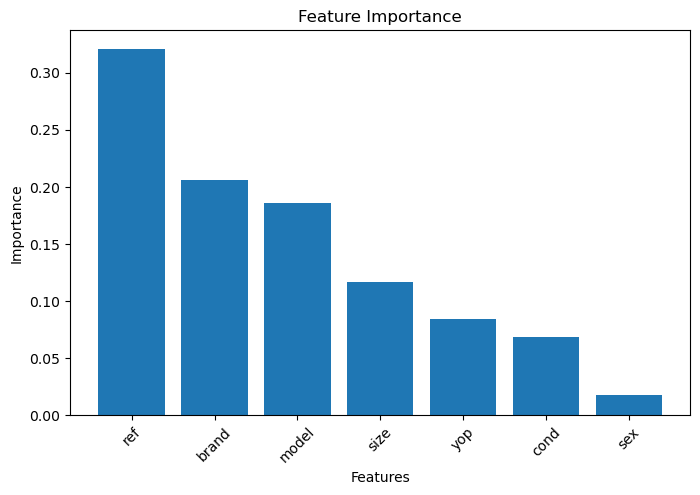

In [35]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"],feature_importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

**The model relies more on high-importance features, while features with lower importance contribute less to price prediction.**

In [36]:
import joblib
joblib.dump(best_rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [37]:
joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

**Tuned Random Forest Regressor achieved the best performance and was selected as the final regression model for watch price prediction.**